In [1]:
import os

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [2]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, z_dim=100, img_dim=784):
        super(Generator, self).__init__()
        self.gen = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )
    def forward(self, x):
        return self.gen(x)

In [3]:
class Discriminator(nn.Module):
    def __init__(self, img_dim=784):
        super(Discriminator, self).__init__()

        self.disc = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.disc(x)

In [1]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Подменяем сломанные ссылки на стабильное зеркало от Google
torchvision.datasets.MNIST.mirrors = [
    'https://storage.googleapis.com/cvdf-datasets/mnist/'
]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset_tv = torchvision.datasets.MNIST(root="../data/MNIST/", train=True, transform=transform, download=True)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.28MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 533kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.01MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.88MB/s]


In [5]:
batch_size = 64
dataloader = DataLoader(dataset_tv, batch_size=batch_size, shuffle=True)

In [6]:
dataset_tv

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../MNIST/
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [7]:
import torch.optim as optim

gen = Generator()
disc = Discriminator()

criterion = nn.BCELoss()

lr = 0.0002
opt_gen = optim.Adam(gen.parameters(), lr=lr)
opt_disc = optim.Adam(disc.parameters(), lr=lr)

In [10]:
epochs = 10
batch_size = 64

for epoch in range(epochs):
    # Теперь мы идем по реальному датасету!
    for batch_idx, (real_images, _) in enumerate(dataloader):

        # 1. Сплющиваем картинки из [64, 1, 28, 28] в [64, 784]
        # -1 означает "высчитай этот размер сам", получается 784
        real_images = real_images.view(real_images.size(0), -1)

        # --- ТВОЙ КОД ОБУЧЕНИЯ ДИСКРИМИНАТОРА ---
        disc_real_output = disc(real_images)
        labels_real = torch.ones_like(disc_real_output)
        loss_disc_real = criterion(disc_real_output, labels_real)

        noise = torch.randn(real_images.size(0), 100) # real_images.size(0) - это текущий размер батча
        fake_images = gen(noise)
        disc_fake_output = disc(fake_images.detach())
        labels_fake = torch.zeros_like(disc_fake_output)
        loss_disc_fake = criterion(disc_fake_output, labels_fake)

        loss_disc = (loss_disc_fake + loss_disc_real) / 2
        opt_disc.zero_grad()
        loss_disc.backward()
        opt_disc.step()

        if batch_idx % 100 != 0:
            output = disc(fake_images)
            loss_gen = criterion(output, torch.ones_like(output))

            opt_gen.zero_grad()
            loss_gen.backward()
            opt_gen.step()
        if batch_idx % 100 == 1:
            print(f"Эпоха [{epoch}/{epochs}] | Батч [{batch_idx}/{len(dataloader)}] |Loss D: {loss_disc.item():.4f} | Loss G: {loss_gen.item():.4f}")

Эпоха [0/10] | Батч [1/938] |Loss D: 0.4967 | Loss G: 0.6918
Эпоха [0/10] | Батч [101/938] |Loss D: 0.2061 | Loss G: 1.6242
Эпоха [0/10] | Батч [201/938] |Loss D: 0.2059 | Loss G: 1.2254
Эпоха [0/10] | Батч [301/938] |Loss D: 0.1477 | Loss G: 1.6807
Эпоха [0/10] | Батч [401/938] |Loss D: 0.1176 | Loss G: 7.3671
Эпоха [0/10] | Батч [501/938] |Loss D: 0.2590 | Loss G: 5.1589
Эпоха [0/10] | Батч [601/938] |Loss D: 0.0052 | Loss G: 7.5507
Эпоха [0/10] | Батч [701/938] |Loss D: 0.0660 | Loss G: 10.8641
Эпоха [0/10] | Батч [801/938] |Loss D: 0.0585 | Loss G: 5.1298
Эпоха [0/10] | Батч [901/938] |Loss D: 0.1120 | Loss G: 17.9184
Эпоха [1/10] | Батч [1/938] |Loss D: 0.1061 | Loss G: 28.6336
Эпоха [1/10] | Батч [101/938] |Loss D: 0.0641 | Loss G: 6.5686
Эпоха [1/10] | Батч [201/938] |Loss D: 0.6095 | Loss G: 6.8296
Эпоха [1/10] | Батч [301/938] |Loss D: 0.1302 | Loss G: 13.5688
Эпоха [1/10] | Батч [401/938] |Loss D: 0.2589 | Loss G: 5.5046
Эпоха [1/10] | Батч [501/938] |Loss D: 0.4946 | Loss G:

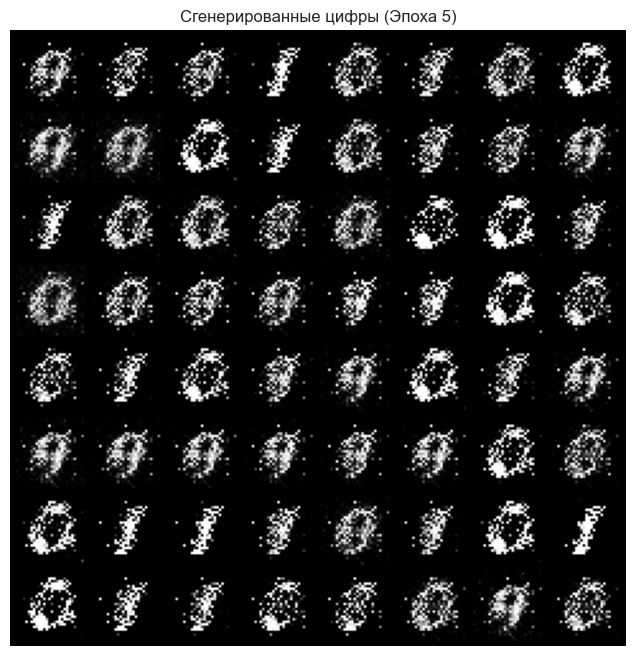

In [11]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# Переводим генератор в режим оценки
gen.eval()

with torch.no_grad():
    # Генерируем 64 случайных вектора шума
    test_noise = torch.randn(64, 100)

    # Пропускаем через генератор
    generated_images = gen(test_noise)

    # Генератор выдал плоские векторы (64, 784).
    # Возвращаем им форму картинок (64, 1, 28, 28)
    generated_images = generated_images.view(-1, 1, 28, 28)

    # Денормализуем картинки из [-1, 1] обратно в [0, 1] для красивой отрисовки
    generated_images = (generated_images + 1) / 2

    # Создаем красивую сетку 8x8
    grid = vutils.make_grid(generated_images, nrow=8, padding=2, normalize=False)

    # Отрисовываем
    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title("Сгенерированные цифры (Эпоха 5)")
    # PyTorch хранит каналы как (C, H, W), а matplotlib ждет (H, W, C)
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.show()